# K-means Clustering

### Import resources and display image

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


%matplotlib inline

In [2]:
IMG = '../../../img'

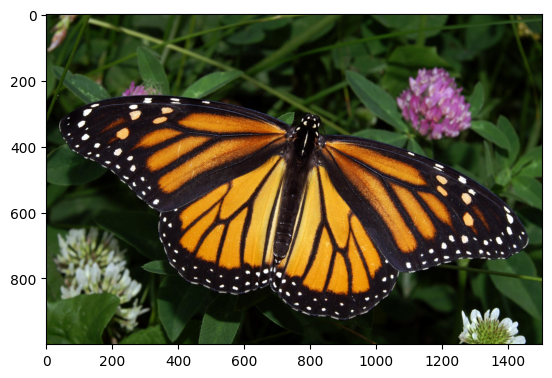

In [3]:
image = cv2.imread(f'{IMG}/monarch.jpg')
# Resize to half of the original
resized_image = cv2.resize(
    image, (image.shape[1] // 2, image.shape[0] // 2)) 
resized_image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB)
plt.imshow(resized_image);

### Prepare data for k-means

In [4]:
# Reshape image into a 2D array of pixels and 3 color values (RGB)
pixel_vals = resized_image.reshape((-1,3))
pixel_vals = np.float32(pixel_vals)

### Implement k-means clustering

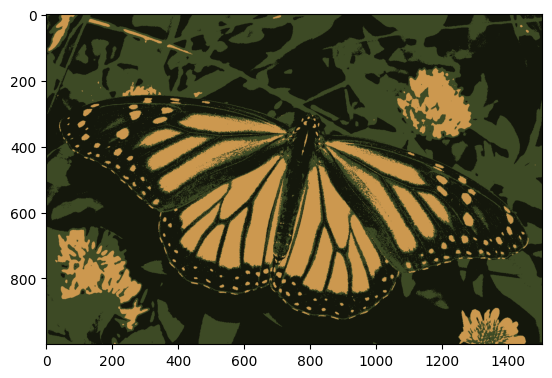

In [5]:
# define stopping criteria
# you can change the number of max iterations for faster convergence!
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)

## TODO: Select a value for k
# then perform k-means clustering
k = 3
retval, labels, centers = cv2.kmeans(
    pixel_vals, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
centers = np.uint8(centers)
segmented_data = centers[labels.flatten()]
segmented_image = segmented_data.reshape((resized_image.shape))
labels_reshape = labels.reshape(
    resized_image.shape[0], resized_image.shape[1])
plt.imshow(segmented_image);

In [ ]:
## TODO: Visualize one segment, try to find which is the leaves, background, etc!

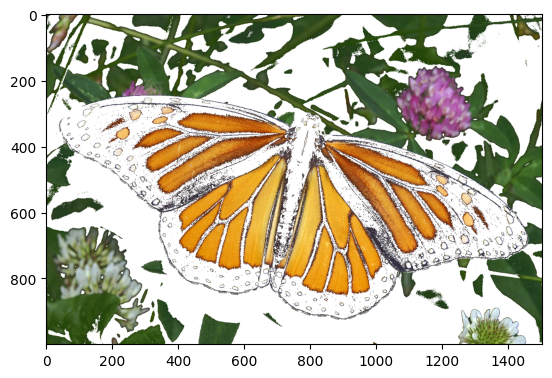

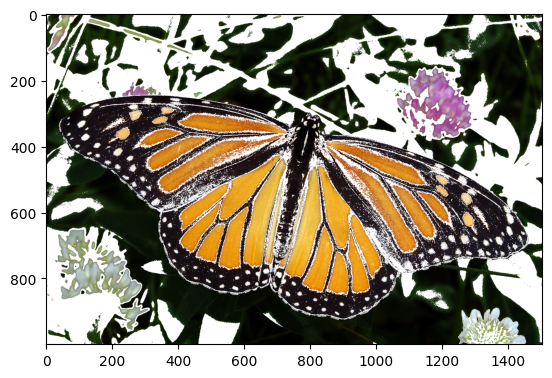

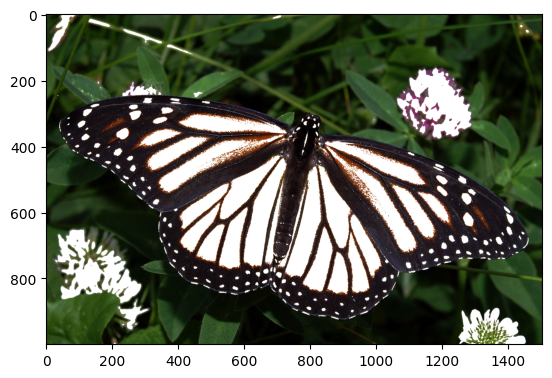

In [11]:
# mask an image segment by cluster
for cluster in range(k):
    masked_image = np.copy(resized_image)
    masked_image[labels_reshape == cluster] = [255, 255, 255]
    plt.imshow(masked_image)
    plt.show();